# Домашнее задание. Работа с пропусками и переменными

## 🎯 Цели задания

1. Научиться анализировать пропуски в данных.
2. Понять различные методы восстановления пропущенных значений.
3. Освоить методы масштабирования признаков.
4. Научиться кодировать категориальные переменные.
5. Понять важность валидации предобработки данных.
6. Работать с реальным датасетом Loan Prediction.

## 🧩 Задание

### Работайте с датасетом train.csv из архива Loan Prediction.

### Анализ пропусков

1. Для каждого столбца с пропусками рассчитайте % пропусков и определите тип переменной (числовая/категориальная).
2. На основе % пропусков и доменной логики составьте «матрицу решений»: какой метод применить к каждому столбцу.

In [ ]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# загрузка датасет train.csv
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
# типы данных столбцов
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [ ]:
# уникальные значения в категориальных столбцах
print(f"Уникальные значения столбца Gender: {df['Gender'].unique()}")
print(f"Уникальные значения столбца Married: {df['Married'].unique()}")
print(f"Уникальные значения столбца Dependents: {df['Dependents'].unique()}")
print(f"Уникальные значения столбца Education: {df['Education'].unique()}")
print(f"Уникальные значения столбца Self_Employed: {df['Self_Employed'].unique()}")
print(f"Уникальные значения столбца Property_Area: {df['Property_Area'].unique()}")
print(f"Уникальные значения столбца Loan_Status: {df['Loan_Status'].unique()}")

Уникальные значения столбца Gender: ['Male' 'Female' nan]
Уникальные значения столбца Married: ['No' 'Yes' nan]
Уникальные значения столбца Dependents: ['0' '1' '2' '3+' nan]
Уникальные значения столбца Education: ['Graduate' 'Not Graduate']
Уникальные значения столбца Self_Employed: ['No' 'Yes' nan]
Уникальные значения столбца Property_Area: ['Urban' 'Rural' 'Semiurban']
Уникальные значения столбца Loan_Status: ['Y' 'N']


In [ ]:
# анализ пропусков в данных, % пропусков в столбцах
(df.isna().mean()*100).round(2)

,0
Loan_ID,0.00
Gender,2.12
Married,0.49
Dependents,2.44
Education,0.00
Self_Employed,5.21
ApplicantIncome,0.00
CoapplicantIncome,0.00
LoanAmount,3.58
Loan_Amount_Term,2.28


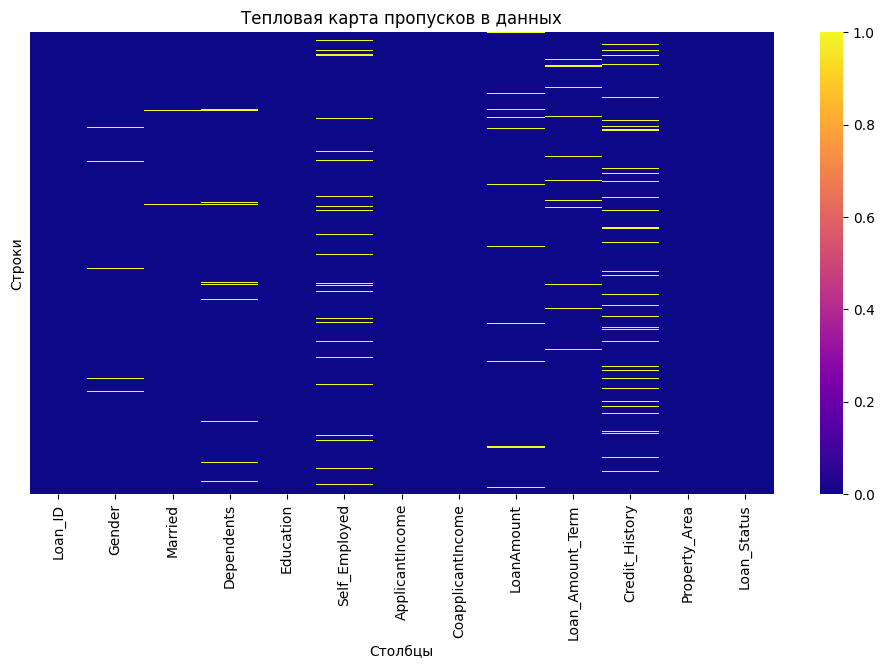

In [ ]:
# визуализация пропусков с помощью seaborn.heatmap
plt.figure(figsize=(12,6))

sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='plasma')
plt.title('Тепловая карта пропусков в данных')
plt.xlabel('Столбцы')
plt.ylabel('Строки')
plt.show()

In [ ]:
# матрица решений
decision_matrix = pd.DataFrame({
    'Признак(столбец)' : [
        'Gender',
        'Married',
        'Dependents',
        'Self_Employed',
        'LoanAmount',
        'Loan_Amount_Term',
        'Credit_History'
    ],
    '% пропусков' : [
        (df['Gender'].isna().mean()*100).round(2),
        (df['Married'].isna().mean()*100).round(2),
        (df['Dependents'].isna().mean()*100).round(2),
        (df['Self_Employed'].isna().mean()*100).round(2),
        (df['LoanAmount'].isna().mean()*100).round(2),
        (df['Loan_Amount_Term'].isna().mean()*100).round(2),
        (df['Credit_History'].isna().mean()*100).round(2)
    ],
    'dtype' : [
        str(df['Gender'].dtype),
        str(df['Married'].dtype),
        str(df['Dependents'].dtype),
        str(df['Self_Employed'].dtype),
        str(df['LoanAmount'].dtype),
        str(df['Loan_Amount_Term'].dtype),
        str(df['Credit_History'].dtype)
    ],
    'Тип переменной (смысловой)' : [
        'категориальный',
        'категориальный',
        'категориальный',
        'категориальный',
        'числовой непрерывный',
        'числовой дискретный',
        'числовой бинарный'
    ],
    'Метод  восстановления пропусков' : [
        'мода',
        'мода',
        'мода',
        'мода',
        'медиана + индикатор пропуска',
        'мода',
        'мода'
    ],
    'Обоснование метода' : [
        'категориальный признак с небольшой долей пропусков',
        'категориальный признак с небольшой долей пропусков',
        'категориальный признак с небольшой долей пропусков',
        'категориальный признак с небольшой долей пропусков',
        'числовой признак, медиана устойчива к выбросам',
        'признак принимает ограниченное число значений',
        'бинарный признак, удаление приведет к потере данных'
    ]
})

pd.set_option('display.max_colwidth', None)

decision_matrix

,Признак(столбец),% пропусков,dtype,Тип переменной (смысловой),Метод восстановления пропусков,Обоснование метода
0,Gender,2.12,object,категориальный,мода,категориальный признак с небольшой долей пропусков
1,Married,0.49,object,категориальный,мода,категориальный признак с небольшой долей пропусков
2,Dependents,2.44,object,категориальный,мода,категориальный признак с небольшой долей пропусков
3,Self_Employed,5.21,object,категориальный,мода,категориальный признак с небольшой долей пропусков
4,LoanAmount,3.58,float64,числовой непрерывный,медиана + индикатор пропуска,"числовой признак, медиана устойчива к выбросам"
5,Loan_Amount_Term,2.28,float64,числовой дискретный,мода,признак принимает ограниченное число значений
6,Credit_History,8.14,float64,числовой бинарный,мода,"бинарный признак, удаление приведет к потере данных"


### Восстановление пропусков

1. Примените метод на выбор к одному числовому признаку с пропусками (например, LoanAmount):
   - медиана + индикатор пропуска
   - модельное восстановление
2. Визуализируйте распределения до обработки и после каждого метода (гистограммы + ящики с усами).

##### Восстановление LoanAmount методом "медиана + индикатор пропусков"

In [ ]:
# создание копии датасета
df_clean = df.copy()

# метод восстановления пропусков "медиана + индикатор пропуска" для LoanAmount
df_clean['LoanAmount Missing'] = df_clean['LoanAmount'].isna().astype(int)
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(
    df_clean['LoanAmount'].median()
    )

# проверка отсутствия пропусков и корректности создания индикатора пропуска
print(
    f'Пропуски в LoanAmount после обработки: '
    f"{df_clean['LoanAmount'].isna().sum()}"
    )
print('\nРаспределение пропусков и непропусков в LoanAmount до обработки:')
print(f"Количество непропусков: {df['LoanAmount'].notna().sum()}")
print(f"Количество пропусков: {df['LoanAmount'].isna().sum()}")
print('\nРаспределение пропусков/непропусков в LoanAmount Missing после обработки:')
df_clean['LoanAmount Missing'].value_counts()

Пропуски в LoanAmount после обработки: 0

Распределение пропусков и непропусков в LoanAmount до обработки:
Количество непропусков: 592
Количество пропусков: 22

Распределение пропусков/непропусков в LoanAmount Missing после обработки:


,count
LoanAmount Missing,
0,592
1,22


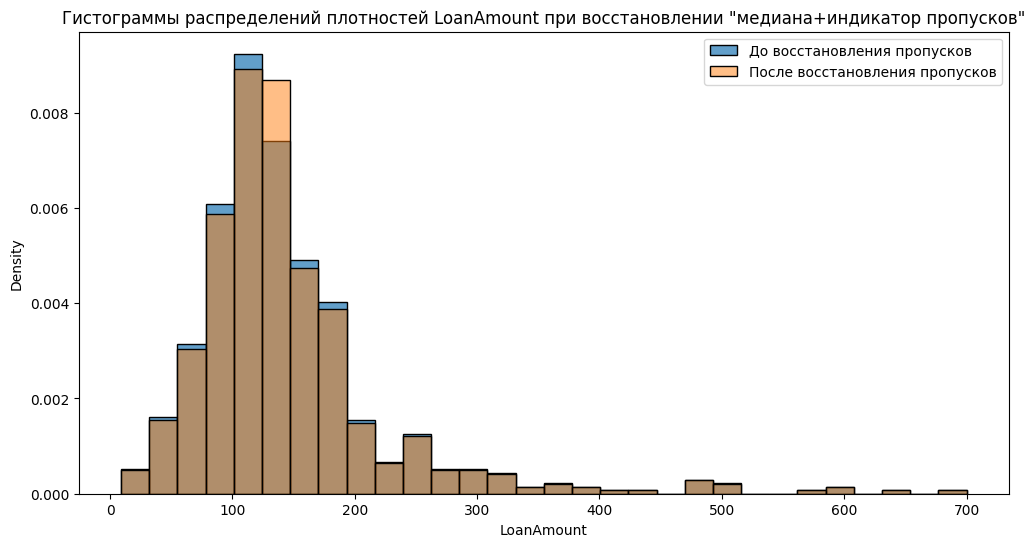

In [ ]:
# Визуализация распределений до и после восстановления с помощью медианы + индикатора пропуска
plt.figure(figsize=(12,6))

sns.histplot(
    df['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.7,
    label='До восстановления пропусков'
    )

sns.histplot(
    df_clean['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.5,
    label='После восстановления пропусков'
    )

plt.title('Гистограммы распределений плотностей LoanAmount при восстановлении "медиана+индикатор пропусков"')
plt.xlabel('LoanAmount')
plt.legend()
plt.show()

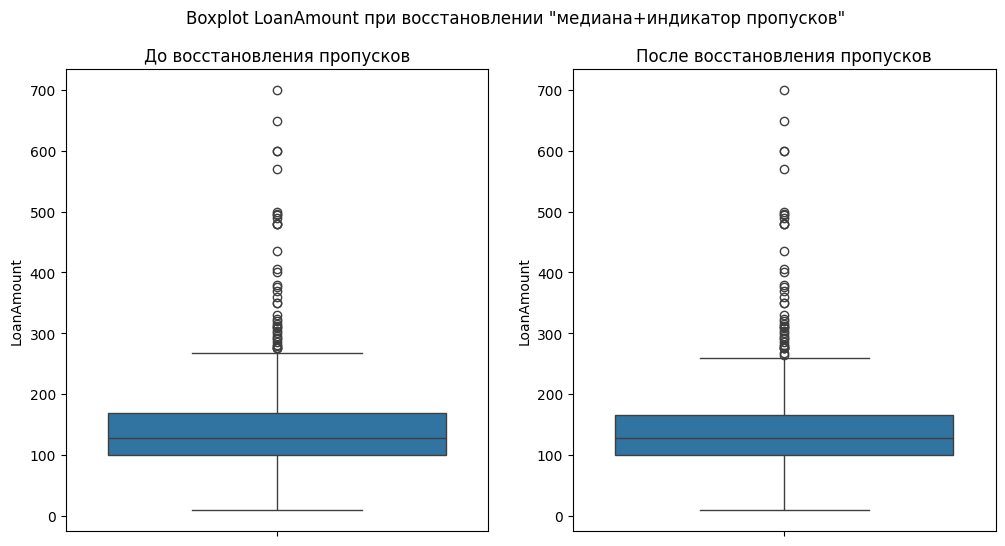

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle('Boxplot LoanAmount при восстановлении "медиана+индикатор пропусков"')

sns.boxplot(y=df['LoanAmount'], ax=axes[0])
axes[0].set_title('До восстановления пропусков')

sns.boxplot(y=df_clean['LoanAmount'], ax=axes[1])
axes[1].set_title('После восстановления пропусков')

plt.show()

##### Модельное восстановление LoanAmount

##### Линейная регрессия

In [ ]:
df_model = df.copy()

df_model_loan_notna = df_model[df_model['LoanAmount'].notna()].copy()
df_model_loan_isna = df_model[df_model['LoanAmount'].isna()].copy()

print(df_model_loan_notna.shape)
print(df_model_loan_isna.shape)

(592, 13)
(22, 13)


In [ ]:
# заполнение пропусков в других признаках их первой модой
for col in [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
    ]:
    mode_ = df_model_loan_notna[col].mode()[0]

    df_model_loan_notna[col] = df_model_loan_notna[col].fillna(mode_)
    df_model_loan_isna[col] = df_model_loan_isna[col].fillna(mode_)

In [ ]:
# целевая переменная
y = df_model_loan_notna['LoanAmount']

# формирование признаков для обучения модели
X_train = df_model_loan_notna.drop(columns=['LoanAmount', 'Loan_Status'])

# формирование признаков для тех строк, где нужно восстановить LoanAmount
X_pred = df_model_loan_isna.drop(columns=['LoanAmount', 'Loan_Status'])

# совместное кодирование обучающей и предсказывающей частей
X_full = pd.concat([X_train, X_pred], axis=0)
X_full = pd.get_dummies(X_full, drop_first=True)

# разделение обучающей и предсказывающей частей
X_train_encoded = X_full.iloc[:len(X_train)]
X_pred_encoded = X_full.iloc[len(X_train):]

# обучение модели линейной регрессии
lin_model = LinearRegression()
lin_model.fit(X_train_encoded, y)

LinearRegression()

In [ ]:
# предсказание пропущенных значений LoanAmount
loan_pred_lin = lin_model.predict(X_pred_encoded)

In [ ]:
# проверка соответствия размеров предсказанных значений и количества пропусков
len(loan_pred_lin) == df_model['LoanAmount'].isna().sum()

np.True_

In [ ]:
# заполнение пропусков LoanAmount
df_lin_model = df_model.copy()
df_lin_model.loc[df_lin_model['LoanAmount'].isna(), 'LoanAmount'] = loan_pred_lin

In [ ]:
# проверка заполнения пропусков
df_lin_model['LoanAmount'].isna().sum()

np.int64(0)

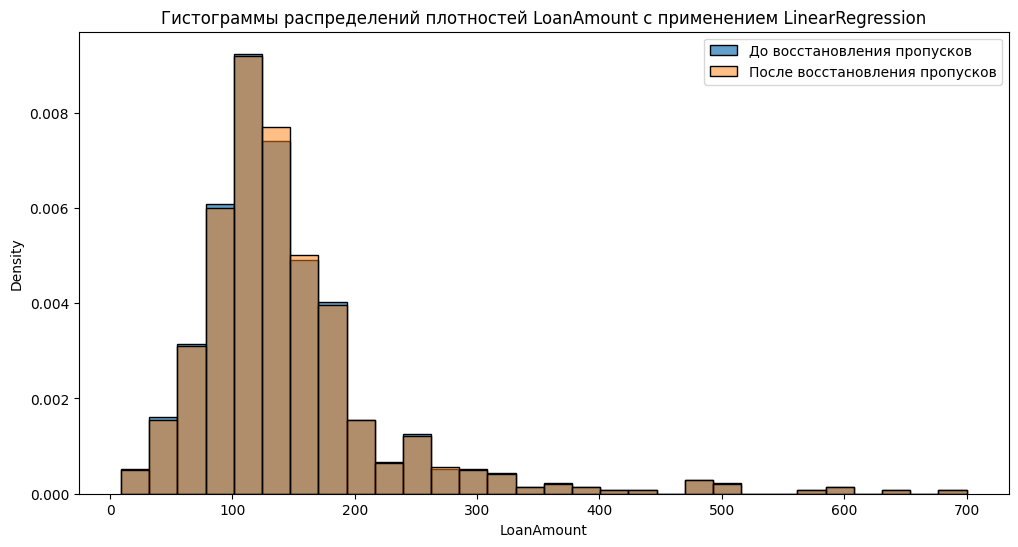

In [ ]:
# Визуализация распределений до и после модельного восстановления
plt.figure(figsize=(12,6))

sns.histplot(
    df['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.7,
    label='До восстановления пропусков'
    )

sns.histplot(
    df_lin_model['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.5,
    label='После восстановления пропусков'
    )

plt.title('Гистограммы распределений плотностей LoanAmount с применением LinearRegression')
plt.xlabel('LoanAmount')
plt.legend()
plt.show()

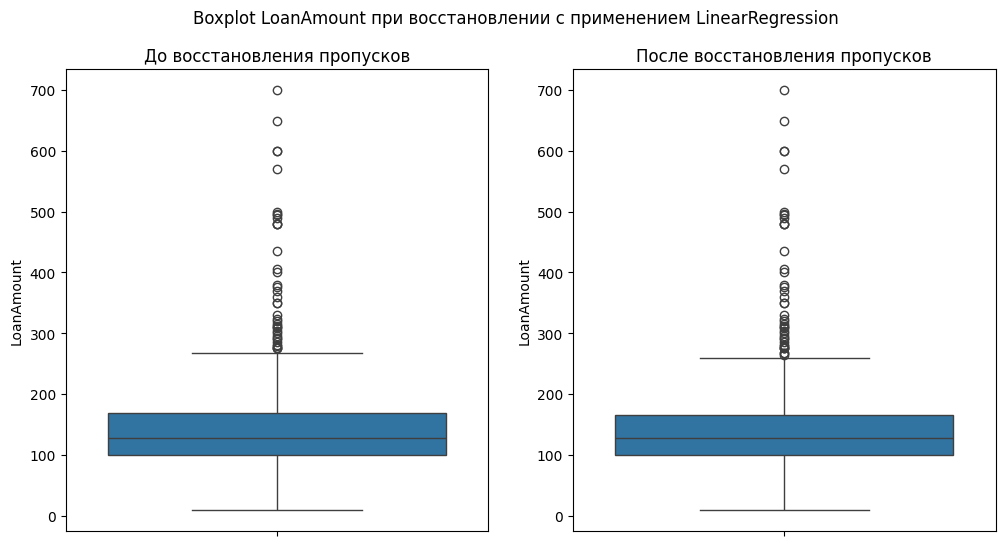

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle('Boxplot LoanAmount при восстановлении с применением LinearRegression')

sns.boxplot(y=df['LoanAmount'], ax=axes[0])
axes[0].set_title('До восстановления пропусков')

sns.boxplot(y=df_lin_model['LoanAmount'], ax=axes[1])
axes[1].set_title('После восстановления пропусков')

plt.show()

##### Восстановление с помощью RandomForest

In [ ]:
# применение RandomForest и обучение модели
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_encoded, y)

# предсказание пропущенных значений LoanAmount
loan_pred_rf = rf_model.predict(X_pred_encoded)

In [ ]:
# проверка соответствия размеров предсказанных значений и количества пропусков
len(loan_pred_rf) == df_model['LoanAmount'].isna().sum()

np.True_

In [ ]:
# заполнение пропусков LoanAmount
df_rf_model = df_model.copy()
df_rf_model.loc[df_rf_model['LoanAmount'].isna(), 'LoanAmount'] = loan_pred_rf

In [ ]:
# проверка заполнения пропусков
df_rf_model['LoanAmount'].isna().sum()

np.int64(0)

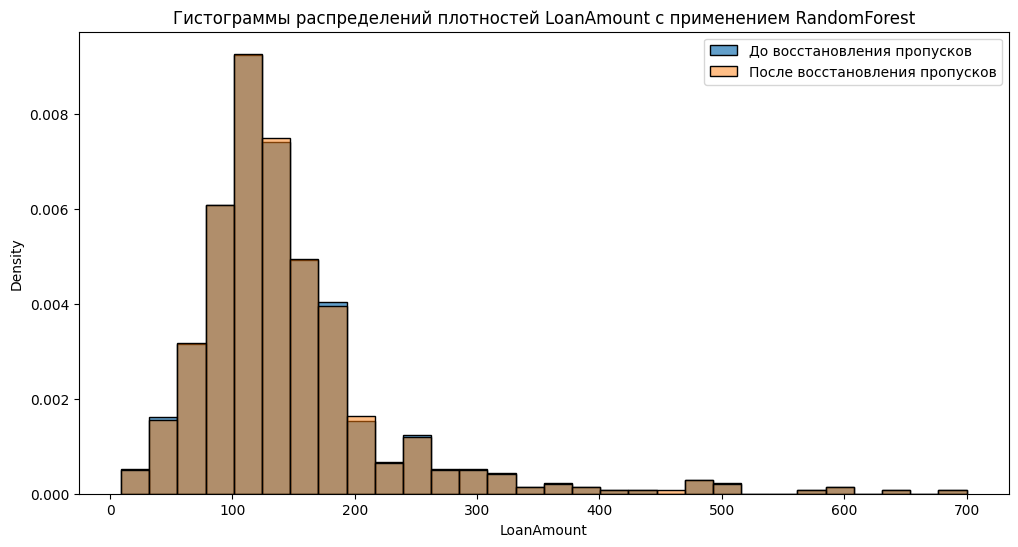

In [ ]:
# Визуализация распределений до и после модельного восстановления
plt.figure(figsize=(12,6))

sns.histplot(
    df['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.7,
    label='До восстановления пропусков'
    )

sns.histplot(
    df_rf_model['LoanAmount'],
    bins=30,
    stat='density',
    alpha=0.5,
    label='После восстановления пропусков'
    )

plt.title('Гистограммы распределений плотностей LoanAmount с применением RandomForest')
plt.xlabel('LoanAmount')
plt.legend()
plt.show()

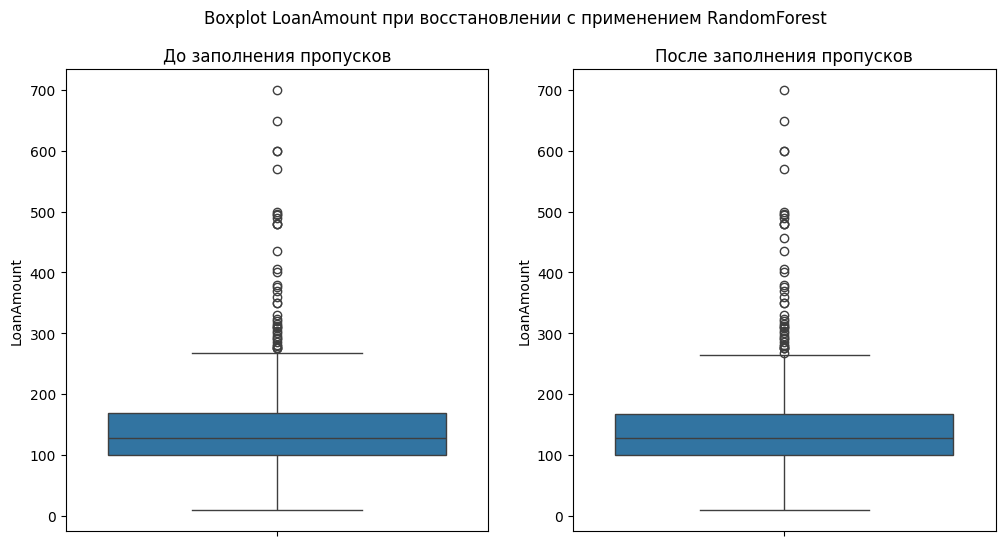

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle('Boxplot LoanAmount при восстановлении с применением RandomForest')

sns.boxplot(y=df['LoanAmount'], ax=axes[0])
axes[0].set_title('До заполнения пропусков')

sns.boxplot(y=df_rf_model['LoanAmount'], ax=axes[1])
axes[1].set_title('После заполнения пропусков')

plt.show()

Результат модельного восстановления пропусков `LoanAmount` - датасет `df_rf_model` - был выбран для дальнейшей предобработки в подзадачах *"Кодирование категориальных переменных"* и *"Валидация предобработки"*, в связи с более лучшим визуальным результатом восстановления

### Масштабирование

1. Выберите 2 числовых признака.
2. Примените к каждому признаку:
   - Минимаксную нормализацию
   - Z-нормализацию
3. Визуализируйте гистограммы до и после каждого преобразования. Сделайте вывод: какой метод лучше подошёл для каждого типа распределения.

In [ ]:
df_scaled = df.copy()

In [ ]:
# минимаксная нормализация ApplicantIncome и CoapplicantIncome
minmax = MinMaxScaler()
df_scaled['ApplicantIncome_minmax'] = minmax.fit_transform(
    df_scaled[['ApplicantIncome']]
    )
df_scaled['CoapplicantIncome_minmax'] = minmax.fit_transform(
    df_scaled[['CoapplicantIncome']]
    )

# Z-нормализация ApplicantIncome и CoapplicantIncome
zscore = StandardScaler()
df_scaled['ApplicantIncome_zscore'] = zscore.fit_transform(
    df_scaled[['ApplicantIncome']]
    )
df_scaled['CoapplicantIncome_zscore'] = zscore.fit_transform(
    df_scaled[['CoapplicantIncome']]
    )

In [ ]:
# функция масштабирования
def scaled_feature_plot(original_feature, scaled_feature, scale_name):
    """
    Строит два боксплота для визуального сравнения распределения признака
    до и после масштабирования.
    Функция создает figure с двумя графиками, расположенными рядом:
    на левом отображается исходное распределение, на правом —
    масштабированное. Это позволяет наглядно оценить изменения
    в распределении данных после применения масштабирования.
    Parameters
    ----------
    original_feature : pandas.Series
        Исходный признак (до масштабирования).
    scaled_feature : pandas.Series
        Признак после применения масштабирования.
    scale_name : str
        Название метода масштабирования (например, 'MinMaxScaler' или 'StandardScaler'),
        которое будет выведено в качестве заголовка графика.
    Returns
    -------
    None
        Функция отображает график с помощью plt.show() и ничего не возвращает.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12,6))
    fig.suptitle(scale_name, fontsize=14)

    sns.histplot(
        original_feature,
        bins=30,
        kde=True,
        ax=axes[0]
        )
    axes[0].set_title('До масштабирования')
    axes[0].set_xlabel(original_feature.name)

    sns.histplot(
        scaled_feature,
        bins=30,
        kde=True,
        ax=axes[1]
        )
    axes[1].set_title('После масштабирования')
    axes[1].set_xlabel(scaled_feature.name)

    plt.tight_layout()
    plt.show()

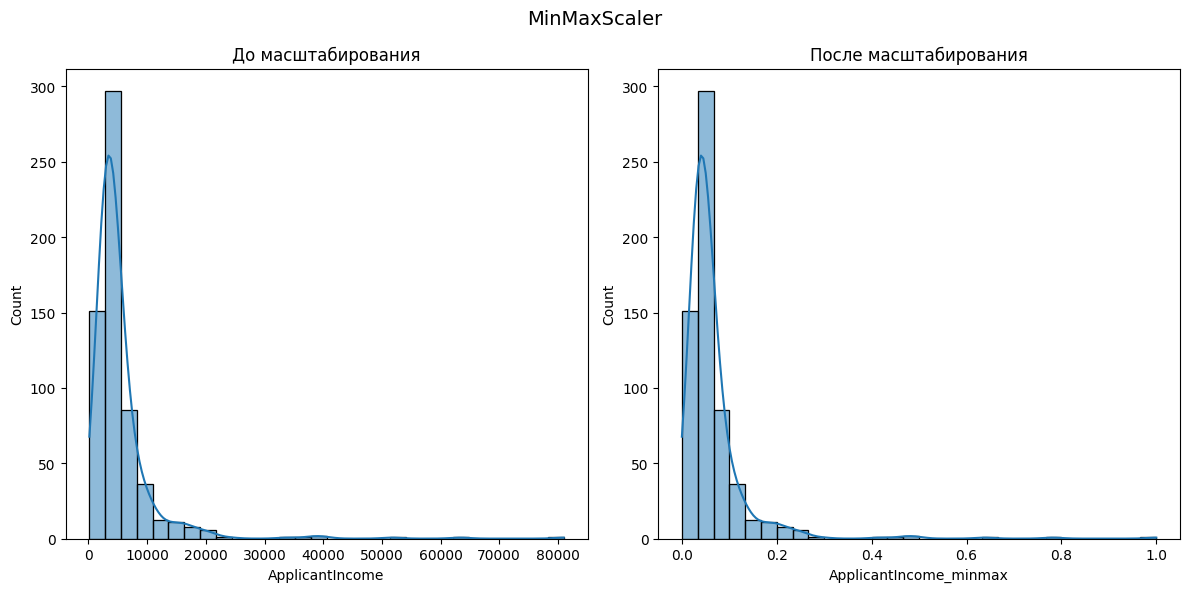

In [ ]:
scaled_feature_plot(
    df_scaled['ApplicantIncome'],
    df_scaled['ApplicantIncome_minmax'],
    'MinMaxScaler'
)

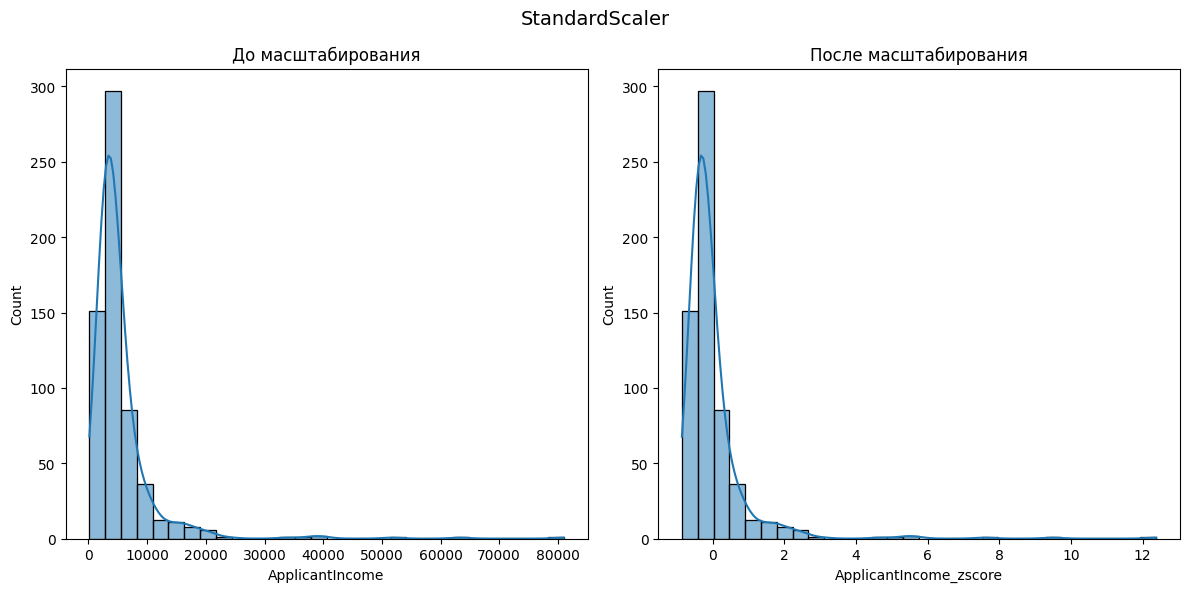

In [ ]:
scaled_feature_plot(
    df_scaled['ApplicantIncome'],
    df_scaled['ApplicantIncome_zscore'],
    'StandardScaler'
)

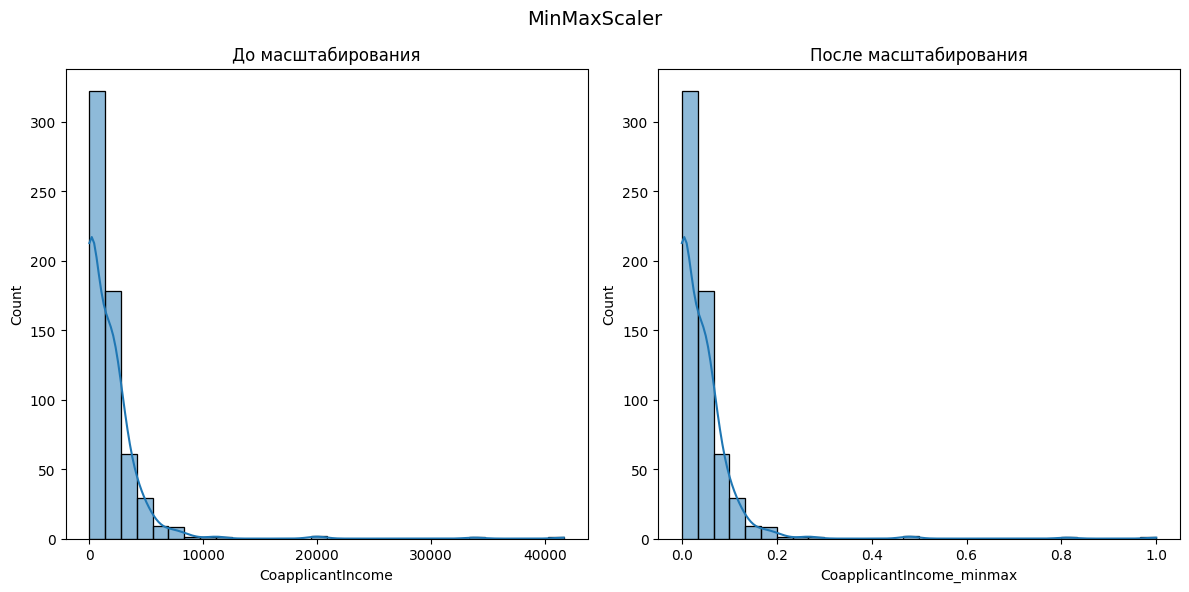

In [ ]:
scaled_feature_plot(
    df_scaled['CoapplicantIncome'],
    df_scaled['CoapplicantIncome_minmax'],
    'MinMaxScaler'
)

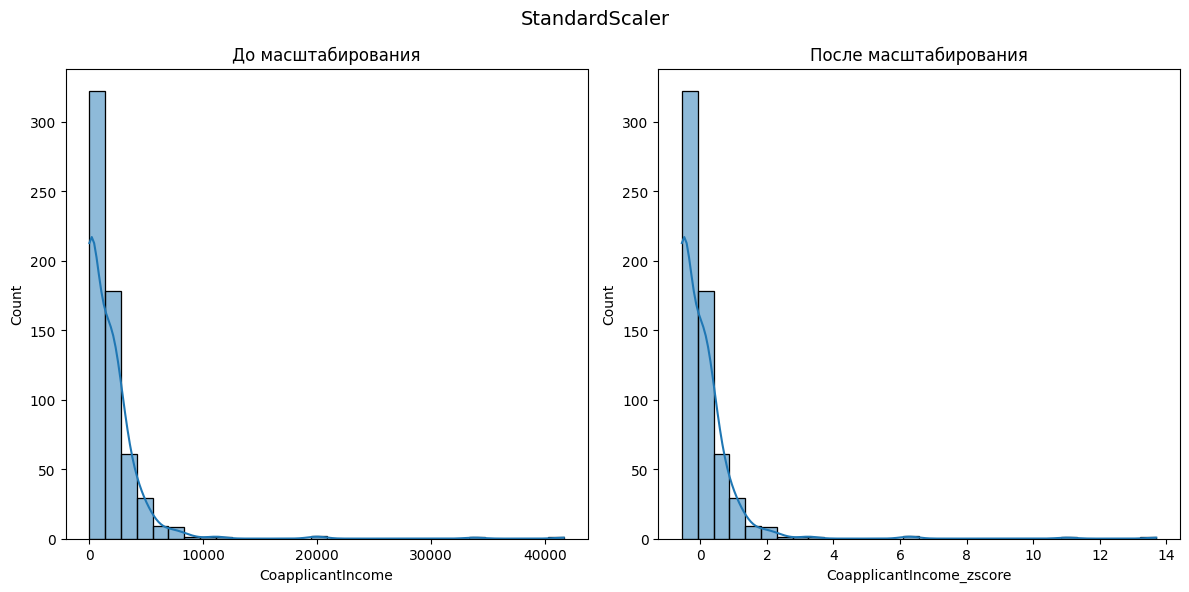

In [ ]:
scaled_feature_plot(
    df_scaled['CoapplicantIncome'],
    df_scaled['CoapplicantIncome_zscore'],
    'StandardScaler'
)

In [ ]:
# коэффициенты ассимметрии
print(df_scaled[['ApplicantIncome', 'CoapplicantIncome']].skew())

ApplicantIncome      6.539513
CoapplicantIncome    7.491531
dtype: float64


**ВЫВОД:**

*Оба выбранных для масштабирования признака имеют ярко выраженную правую ассиметрию, и ни минимаксная, ни Z-нормализация не устраняют ассиметрию, сохраняя форму распределения. Для таких сильно ассиметричных распределений, возможно, более полезным преобразованием могло бы быть логарифмирование.*

### Кодирование категориальных переменных

1. Выделите 2 категориальных признака: один порядковый (например, Credit_History), второй номинальный (например, Property_Area).
2. Примените к ним разные методы:
   - для порядкового: OrdinalEncoder (порядковое кодирование)
   - для номинального: OneHotEncoder + сравнение с TargetEncoder (с корректной кросс-валидацией)
3. Проверьте размерность датасета до и после кодирования. Оцените рост числа признаков.

In [ ]:
# пропуски в выбранных для кодирования признаках
# используем для обработки df_rf_model
df_encoded = df_rf_model.copy()

df_encoded[['Dependents', 'Property_Area']].isna().sum()

,0
Dependents,15
Property_Area,0


In [ ]:
# обработка пропусков
df_encoded['Dependents'] = (
    df_encoded['Dependents']
    .fillna(df_encoded['Dependents'].mode()[0])
    )

df_encoded['Dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [ ]:
# порядковое кодирование признака Dependents
ord_encoder = OrdinalEncoder(categories=[['0', '1', '2', '3+']])

df_encoded['Dependents_ordinal'] = ord_encoder.fit_transform(
    df_encoded[['Dependents']]
    )

df_encoded[['Dependents', 'Dependents_ordinal']].head(10)

,Dependents,Dependents_ordinal
0,0,0.0
1,1,1.0
2,0,0.0
3,0,0.0
4,0,0.0
5,2,2.0
6,0,0.0
7,3+,3.0
8,2,2.0
9,1,1.0


In [ ]:
# сравнение размерностей
print(f'Размерность датасета до кодирования: {df_rf_model.shape}')
print(f'Размерность датасета после кодирования: {df_encoded.shape}')

Размерность датасета до кодирования: (614, 13)
Размерность датасета после кодирования: (614, 14)


In [ ]:
# создание копий для OneHot и Target кодирований
df_ohe = df_encoded.copy()
df_target = df_encoded.copy()

In [ ]:
# OneHot кодирование Property_Area
ohe = OneHotEncoder(sparse_output=False, drop='first')

property_area_ohe = ohe.fit_transform(df_ohe[['Property_Area']])

property_area_ohe_df = pd.DataFrame(
    property_area_ohe,
    columns=ohe.get_feature_names_out(['Property_Area']),
    index=df_ohe.index
    )

df_ohe = pd.concat([df_ohe, property_area_ohe_df], axis=1)

df_ohe = df_ohe.drop(columns=['Property_Area'])

In [ ]:
# сравнение размерностей
print(f'Размерность датасета до кодирования: {df_encoded.shape}')
print(f'Размерность датасета после кодирования: {df_ohe.shape}')

Размерность датасета до кодирования: (614, 14)
Размерность датасета после кодирования: (614, 15)


In [ ]:
# Target кодирование Property_Area с корректной кросс-валидацией
df_target['Loan_Status_bin'] = df_target['Loan_Status'].map({'N': 0, 'Y' : 1})

# целевая переменная
y_target = df_target['Loan_Status_bin']

# пустой столбец для будущих кодировок
df_target['Property_Area_target'] = np.nan

# out-of-fold target encoding
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, valid_idx in skf.split(df_target, y_target):

    train_fold = df_target.iloc[train_idx]
    valid_fold = df_target.iloc[valid_idx]

    area_mean = train_fold.groupby('Property_Area')['Loan_Status_bin'].mean()

    df_target.loc[
        valid_fold.index,
        'Property_Area_target'
        ] = valid_fold['Property_Area'].map(area_mean)

# проверка результата
df_target[['Property_Area', 'Property_Area_target']].head(20)

,Property_Area,Property_Area_target
0,Urban,0.654321
1,Rural,0.602837
2,Urban,0.648485
3,Urban,0.664516
4,Urban,0.668712
5,Urban,0.668712
6,Urban,0.656442
7,Semiurban,0.767568
8,Urban,0.654321
9,Semiurban,0.764398


In [ ]:
# удаление исходного признака и служебного Loan_Status_bin
df_target = df_target.drop(columns=['Property_Area', 'Loan_Status_bin'])

In [ ]:
# сравнение размерностей
print(f'Размерность датасета до кодирования Property_Area: {df_encoded.shape}')
print(f'Размерность датасета после OneHotEncoder: {df_ohe.shape}')
print(f'Размерность датасета TargetEncoder: {df_target.shape}')

Размерность датасета до кодирования Property_Area: (614, 14)
Размерность датасета после OneHotEncoder: (614, 15)
Размерность датасета TargetEncoder: (614, 14)


**ВЫВОД:**

*Для порядкового признака `Dependents` было применено порядковое кодирование (`OrdinalEncoder`), что позволило сохранить естественный порядок категорий и представить признак одним числовым столбцом, рост размерности при этом был незначительным (+1 признак), при этом если удалить исходный признак, размерность вовсе можно сохранить прежней.*

*Для номинального признака `Property_Area` были применены два метода. `One-Hot Encoding` увеличил размерность датасета с 14 до 15 признаков, что также являеься незначительным. Рост оказался небольшим, так как использовался `drop='first'` для удаления избыточной категории.
`Target Encoding` не изменил размерность датасета, так как исходный признак был заменён одним новым числовым столбцом.
`One-Hot Encoding` полностью сохраняет информацию о принадлежности к категории, но может увеличивать размерность данных. `Target Encoding` не увеличивает размерность и может быть более эффективным для признаков с большим числом категорий, однако требует особого внимания к предотвращению утечки целевой переменной.*


### Валидация предобработки

1. Обучите логистическую регрессию на двух версиях данных:
   - Версия 1: только удаление строк с пропусками
   - Версия 2: датасет с обработанными признаками
2. Сравните ROC-AUC на валидационной выборке. Сделайте вывод о влиянии качества предобработки на метрику.

In [ ]:
# создание копий датасетов для Версии 1 и Версии 2
df_dropna = df.copy()
df_final_clean = df_ohe.copy()

# удаление строк с пропусками для Версии 1
df_dropna = df_dropna.dropna()

# проверка на пропуски
print(f'Сумма пропусков в датасете Версии 1: {df_dropna.isna().sum().sum()}')
print(f'\nПропуски в датасете Версии 2:\n{df_final_clean.isna().sum()}')


Сумма пропусков в датасете Версии 1: 0

Пропуски в датасете Версии 2:
Loan_ID                     0
Gender                     13
Married                     3
Dependents                  0
Education                   0
Self_Employed              32
ApplicantIncome             0
CoapplicantIncome           0
LoanAmount                  0
Loan_Amount_Term           14
Credit_History             50
Loan_Status                 0
Dependents_ordinal          0
Property_Area_Semiurban     0
Property_Area_Urban         0
dtype: int64


In [ ]:
# восстановление пропусков признаков в датасете Версии 2 их первой модой
for col in [
    'Gender',
    'Married',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
    ]:
    mode_ = df_final_clean[col].mode()[0]

    df_final_clean[col] = df_final_clean[col].fillna(mode_)

# проверка восстановления
df_final_clean.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Кодирование оставшихся категориальных признаков

In [ ]:
print(
    f'Оставшиеся категориальные признаки в датасете Версии 1:\n '
    f"{df_dropna.select_dtypes(include='object').columns}"
    )
print(
    f'Оставшиеся категориальные признаки в датасете Версии 2:\n '
    f"{df_final_clean.select_dtypes(include='object').columns}"
    )

Оставшиеся категориальные признаки в датасете Версии 1:
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')
Оставшиеся категориальные признаки в датасете Версии 2:
 Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Loan_Status'],
      dtype='object')


In [ ]:
# удаление ненужных категориальных столбцов
df_dropna = df_dropna.drop(columns=['Loan_ID', 'Dependents'])
df_final_clean = df_final_clean.drop(columns=['Loan_ID', 'Dependents'])

# кодирование оставшихся категориальных столбцов, кроме целевой переменной Loan_Status
df_dropna = pd.get_dummies(
    df_dropna,
    columns=[
        'Gender',
        'Married',
        'Education',
        'Self_Employed',
        'Property_Area'
    ],
    drop_first=True
)

df_final_clean = pd.get_dummies(
    df_final_clean,
    columns=[
        'Gender',
        'Married',
        'Education',
        'Self_Employed'
    ],
    drop_first=True
)

In [ ]:
# функция для логистической регрессии
def calc_logregr_roc_auc(
        df,
        target_col='Loan_Status',
        test_size=0.2,
        random_state=42,
        max_iter=5000
        ):
    """
    Обучает логистическую регрессию и возвращает метрику ROC-AUC.
    Функция принимает датафрейм с признаками и бинарной целевой переменной,
    выполняет стратифицированное разбиение на обучающую и тестовую выборки,
    обучает модель логистической регрессии и вычисляет ROC-AUC на тестовой выборке.
    Parameters
    ----------
    df : pandas.DataFrame
        Датафрейм, содержащий признаки и целевую переменную.
    target_col : str, default='Loan_Status'
        Название столбца с целевой переменной. Значения должны быть 'N' и 'Y',
        которые будут преобразованы в 0 и 1 соответственно.
    test_size : float, default=0.2
        Доля данных, выделяемая для тестовой выборки (от 0 до 1).
    random_state : int, default=42
        Seed для воспроизводимости разбиения данных и обучения модели.
    max_iter : int, default=5000
        Максимальное количество итераций для сходимости логистической регрессии.
    Returns
    -------
    float
        Значение ROC-AUC на тестовой выборке.
    Examples
    --------
    >>> roc_auc = calc_logregr_roc_auc(df, target_col='Loan_Status')
    >>> print(f'ROC-AUC: {roc_auc:.4f}')
    """
    # целевая переменная
    y_target = df[target_col].map({'N' : 0, 'Y' : 1})

    # признаки
    X = df.drop(columns=[target_col])

    # разделение на train и test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_target,
        test_size=test_size,
        random_state=random_state,
        stratify=y_target
        )

    # модель и обучение
    model = LogisticRegression(max_iter=max_iter, random_state=random_state)
    model.fit(X_train, y_train)

    # вероятности положительного класса
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # roc-auc
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    return roc_auc

In [ ]:
# вычисление и сравнение метрик ROC-AUC для двух версий
roc_auc_dropna = calc_logregr_roc_auc(df_dropna)
roc_auc_preprocessed = calc_logregr_roc_auc(df_final_clean)

print(f'ROC-AUC (удаление пропусков): {roc_auc_dropna:.4f}')
print(f'ROC-AUC (обработанные данные): {roc_auc_preprocessed:.4f}')
print(f'Изменение ROC-AUC при предобработке: {roc_auc_preprocessed - roc_auc_dropna:+.4f}')

ROC-AUC (удаление пропусков): 0.7823
ROC-AUC (обработанные данные): 0.8545
Изменение ROC-AUC при предобработке: +0.0722


**ВЫВОД:**

*Повышение качества предобработки ощутимо улучшило качество модели, повысив метрику ROC-AUC. При предобработке только с удалением строк пропусков ROC-AUС составила 0.7823, а при полноценной предобработке с восстановлением пропусков, кодированием категориальных признаков и сохранением полного объема информации - 0.8545 (+ 7.22%). Полученный прирост показывает важность качественной предобработки в свете сохранения полезной информации и улучшении способности модели различать классы.*

## 📝 Выводы

1. Какой метод обработки пропусков показал лучший баланс между сохранением информации и простотой?

*Для небольших долей пропусков в категориальных признаках эффективным и простым решением оказалось заполнение модой. Для признака `LoanAmount` были рассмотрены как простое восстановление медианой, так и модельное восстановление. Наиболее информативным оказался подход с использованием модели `Random Forest`, поскольку он учитывает взаимосвязи между признаками и позволяет сохранить больше информации, чем простое заполнение статистикой.*

2. Как масштабирование повлияло на распределение признаков?

*Масштабирование изменило диапазон значений признаков, но не изменило форму их распределений. Минимаксная нормализация перевела значения в диапазон [0;1], а Z-нормализация выполнила центрирование относительно нуля и масштабирование по стандартному отклонению. Сильная правосторонняя асимметрия признаков сохранилась после обоих преобразований.*

3. Какой риск утечки таргета был наиболее критичен в задании и как вы его избежали?

*Наиболее существенный риск утечки целевой переменной возникал при использовании `Target Encoding` для признака `Property_Area`. Если вычислять средние значения таргета по всему датасету одновременно, каждая строка будет косвенно использовать информацию о собственном целевом значении. Для предотвращения утечки было применено `Out-of-Fold кодирование с использованием StratifiedKFold`, при котором кодировка каждой строки вычислялась только на основе данных обучающей части соответствующего фолда и не использовала информацию из валидационной части.*

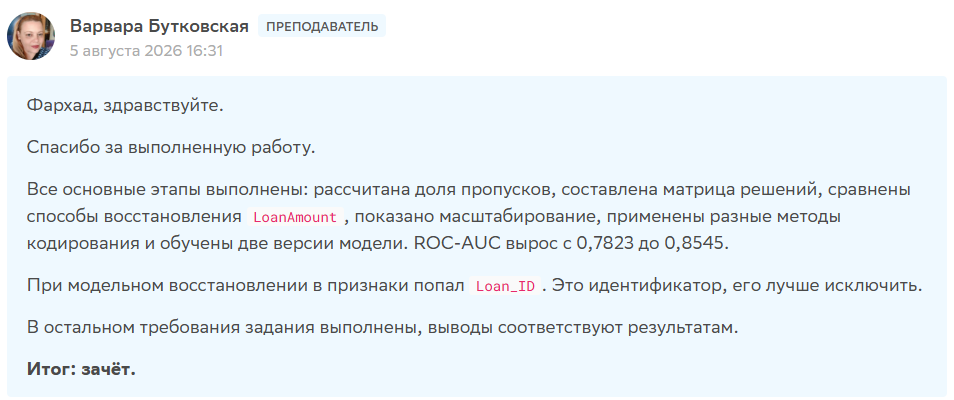